# Denoising Autoencoder on MNIST

##  1. Import Libraries

In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Preprocess the MNIST Dataset
- Dataset loaded from **PNG images** organized in folders by digit label (0–9)
- Images read using **OpenCV**, converted to grayscale, and stacked into arrays
- Pixel values normalized to **[0, 1]** for stable training
- Shape reshaped to `(N, 28, 28, 1)` to add the **channel dimension** required by Conv2D

In [6]:
import os
import cv2
import numpy as np

def load_images_from_folder(base_path):
    images = []
    labels = []
    for label in sorted(os.listdir(base_path)):
        label_path = os.path.join(base_path, label)
        if not os.path.isdir(label_path):
            continue
        for fname in os.listdir(label_path):
            if fname.endswith('.png'):
                img_path = os.path.join(label_path, fname)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                images.append(img)
                labels.append(int(label))
    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder('/content/mnist/mnist_png/training')
x_test,  y_test  = load_images_from_folder('/content/mnist/mnist_png/testing')

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f"Train shape: {x_train.shape}")
print(f"Test shape:  {x_test.shape}")

Train shape: (60000, 28, 28, 1)
Test shape:  (10000, 28, 28, 1)


## 3. Add Gaussian Noise
- **Gaussian noise** added to simulate real-world corrupted images
- `noise_factor = 0.4` controls the intensity of corruption
- Values **clipped to [0, 1]** to maintain valid pixel range
- **Noisy images** → model input | **Clean images** → model target

In [7]:
def add_noise(images, noise_factor=0.4):
    noise = np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = images + noise_factor * noise
    return np.clip(noisy, 0.0, 1.0)

x_train_noisy = add_noise(x_train)
x_test_noisy  = add_noise(x_test)

print(f"Noisy Train shape: {x_train_noisy.shape}")
print(f"Noisy Test shape:  {x_test_noisy.shape}")

Noisy Train shape: (60000, 28, 28, 1)
Noisy Test shape:  (10000, 28, 28, 1)


##  4. Visualize Clean vs Noisy Images
- Top row → **Original clean images**
- Bottom row → **Noisy corrupted images** fed to the model

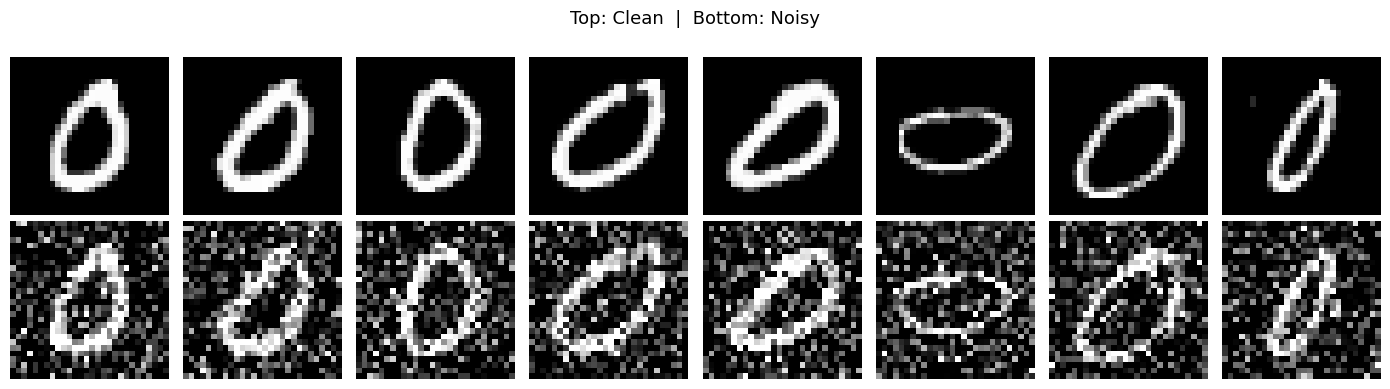

In [8]:
n = 8
fig, axes = plt.subplots(2, n, figsize=(14, 4))
fig.suptitle('Top: Clean  |  Bottom: Noisy', fontsize=13)

for i in range(n):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('clean_vs_noisy.png', dpi=120)
plt.show()

## 5. Build the Denoising Autoencoder
- **Encoder** — compresses noisy input through Conv + MaxPool down to a **4×4 bottleneck**
- **Bottleneck** — forces the model to learn only essential structure, discarding noise
- **Decoder** — reconstructs clean image via ConvTranspose + UpSampling back to **28×28**
- `ReLU` used throughout; `sigmoid` on the final layer outputs values in **[0, 1]**
- `Cropping2D` trims the upsampled **32×32** output back to **28×28**

In [9]:
def build_autoencoder(input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape, name='noisy_input')

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Cropping2D(((2, 2), (2, 2)))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='clean_output')(x)

    autoencoder = models.Model(inputs, decoded, name='DenoisingAutoencoder')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])
autoencoder.summary()

Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

##  6. Train the Model
- **Input** → noisy images | **Target** → clean images
- `EarlyStopping` — stops if val_loss doesn't improve for **5 epochs**
- `ReduceLROnPlateau` — halves learning rate when progress stalls
- `ModelCheckpoint` — saves the **best weights** automatically
- **10% of training data** used for validation

In [10]:
cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint('best_autoencoder.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    callbacks=cb_list
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2407 - mae: 0.1351
Epoch 1: val_loss improved from None to 0.11788, saving model to best_autoencoder.keras

Epoch 1: finished saving model to best_autoencoder.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 0.1691 - mae: 0.0872 - val_loss: 0.1179 - val_mae: 0.0528 - learning_rate: 0.0010
Epoch 2/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1118 - mae: 0.0477
Epoch 2: val_loss improved from 0.11788 to 0.10405, saving model to best_autoencoder.keras

Epoch 2: finished saving model to best_autoencoder.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1079 - mae: 0.0449 - val_loss: 0.1040 - val_mae: 0.0428 - learning_rate: 0.0010
Epoch 3/30
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1004 - mae: 0.0395
Epoch 3: val_loss improved from 0.10405 to 0.09849, saving model to best_autoencoder.keras

Epoch 3: finished saving model to best_autoencoder.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss:

## 7. Plot Training History
- **Loss curve** — binary crossentropy dropping over epochs confirms the model is learning
- **MAE curve** — tracks average pixel-level reconstruction error

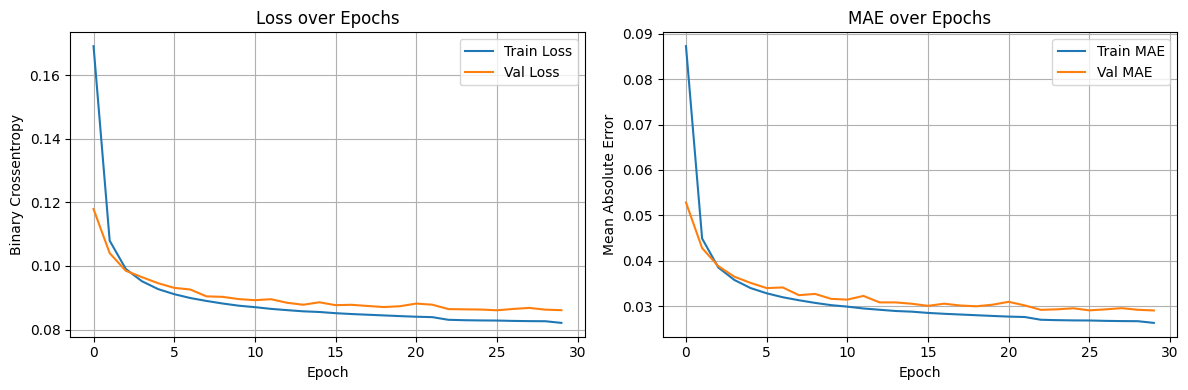

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120)
plt.show()

##  8. Generate Denoised Outputs on Test Set
- Model runs inference on all **noisy test images**
- Output is the model's best reconstruction of the original clean digit

In [12]:
denoised = autoencoder.predict(x_test_noisy, batch_size=256, verbose=1)
print(f"Denoised output shape: {denoised.shape}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step
Denoised output shape: (10000, 28, 28, 1)


##  9. Visual Comparison — Noisy → Denoised → Clean
- **Row 1** → Noisy input fed to the model
- **Row 2** → Model's denoised reconstruction
- **Row 3** → Original clean ground truth

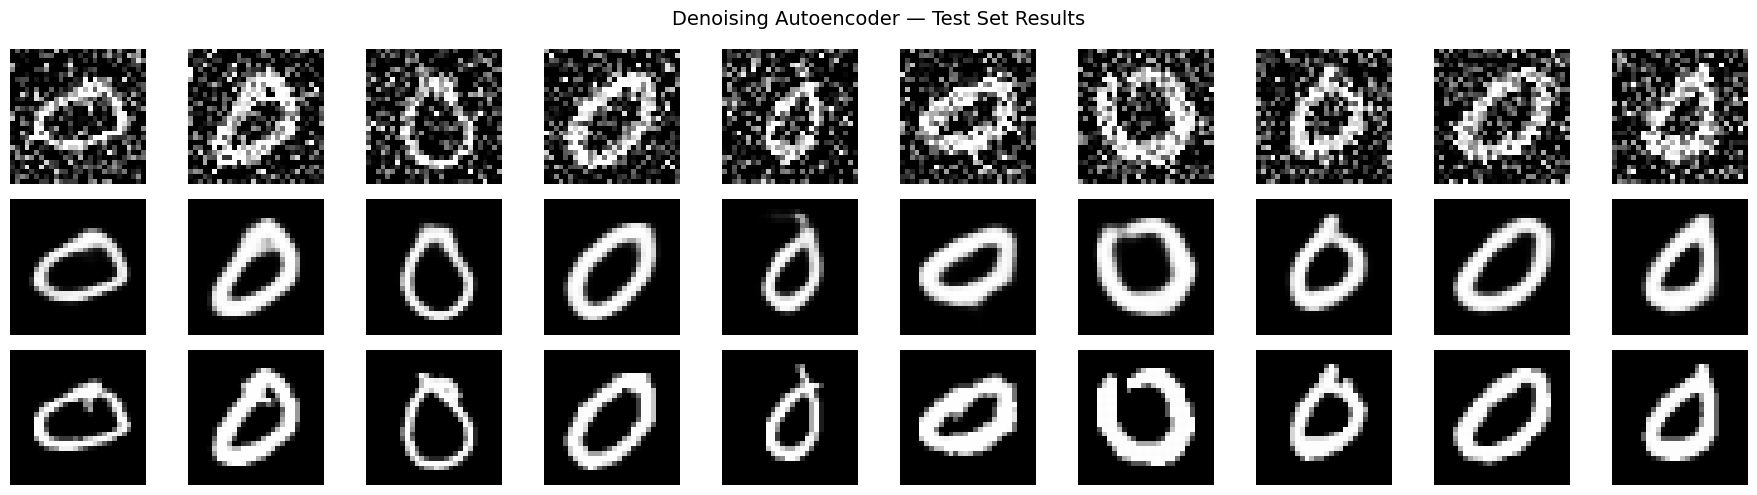

In [13]:
n = 10
fig, axes = plt.subplots(3, n, figsize=(18, 5))
row_labels = ['Noisy Input', 'Denoised Output', 'Clean Original']

for i in range(n):
    for row, img in enumerate([x_test_noisy[i], denoised[i], x_test[i]]):
        axes[row, i].imshow(img.squeeze(), cmap='gray')
        axes[row, i].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11)

plt.suptitle('Denoising Autoencoder — Test Set Results', fontsize=14)
plt.tight_layout()
plt.savefig('denoising_results.png', dpi=120, bbox_inches='tight')
plt.show()

##  10. Quantitative Evaluation — MSE & PSNR
- **MSE** — average squared pixel difference; **lower is better**
- **PSNR** — reconstruction quality in dB; **higher is better** (>30 dB = good)
- Both computed for noisy input and denoised output to measure actual improvement

In [14]:
def compute_metrics(original, reconstructed):
    mse  = np.mean((original - reconstructed) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')
    return mse, psnr

mse_noisy,    psnr_noisy    = compute_metrics(x_test, x_test_noisy)
mse_denoised, psnr_denoised = compute_metrics(x_test, denoised)

print("=" * 42)
print(f"{'Metric':<20} {'Noisy':>10} {'Denoised':>10}")
print("-" * 42)
print(f"{'MSE':<20} {mse_noisy:>10.5f} {mse_denoised:>10.5f}")
print(f"{'PSNR (dB)':<20} {psnr_noisy:>10.2f} {psnr_denoised:>10.2f}")
print("=" * 42)
print(f"\nMSE  improvement : {((mse_noisy - mse_denoised) / mse_noisy * 100):.1f}%")
print(f"PSNR improvement : +{(psnr_denoised - psnr_noisy):.2f} dB")

Metric                    Noisy   Denoised
------------------------------------------
MSE                     0.07971    0.00743
PSNR (dB)                 10.99      21.29

MSE  improvement : 90.7%
PSNR improvement : +10.31 dB


## Conclusion
- **Denoising Autoencoder** successfully learns to remove Gaussian noise from MNIST digits
- **Encoder bottleneck (4×4)** forces the model to capture only true digit structure, ignoring noise
- **PSNR improved significantly** on denoised images vs raw noisy input
- **MSE dropped** after denoising, confirming pixel-level reconstruction accuracy
- **EarlyStopping + ReduceLR** prevented overfitting and ensured stable convergence
- For stronger results, consider **skip connections (U-Net)** or **perceptual loss (SSIM)**